# Notebook 01 — Sparse Recovery: Classical Baselines (ISTA & FISTA)

**Part A** of the HyperLISTA project.

Measurement model: $b = Ax^* + \varepsilon$

This notebook:
1. Generates a synthetic sparse-recovery dataset
2. Sweeps ISTA and FISTA over varying numbers of iterations
3. Plots NMSE (dB) vs. iteration count

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import torch
import matplotlib.pyplot as plt
import pandas as pd

from src.data.sparse_generator import build_sparse_dataloaders
from src.models.ista  import ISTA
from src.models.fista import FISTA
from src.evaluation.metrics import evaluate_model
from src.evaluation.visualizer import plot_nmse_vs_layers, get_layerwise_nmse

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


## 1. Dataset Generation

In [2]:
# Problem dimensions (following the paper: m=250, n=500, s≈50)
M = 250 # Dimensions of the measurement vector
N = 500 # Original signal dimension
S = 50  # Sparsity level (Original signal has S non-zero entries)
SIGMA = 0.0 # noiseless
N_LAYERS = 16   # Number of layers/iterations for ISTA and FISTA

A, train_loader, val_loader, test_loader = build_sparse_dataloaders(
    m=M, n=N, s=S, sigma=SIGMA,
    n_train=10240, n_val=1024, n_test=1024,
    batch_size=256, device=DEVICE,
)
print(f'A: {A.shape},  train batches: {len(train_loader)}')

A: torch.Size([250, 500]),  train batches: 40


## 2. ISTA — Layer-wise NMSE

In [3]:
ista = ISTA(A, lam=0.1, n_iter=N_LAYERS).to(DEVICE)

ista_nmse = get_layerwise_nmse(ista, test_loader, DEVICE)
print('ISTA final NMSE (dB):', round(ista_nmse[-1], 2))

ISTA final NMSE (dB): -5.3


## 3. FISTA — Layer-wise NMSE

In [4]:
fista = FISTA(A, lam=0.1, n_iter=N_LAYERS).to(DEVICE)

fista_nmse = get_layerwise_nmse(fista, test_loader, DEVICE)
print('FISTA final NMSE (dB):', round(fista_nmse[-1], 2))

FISTA final NMSE (dB): -10.92


## 4. λ Sweep (ISTA)

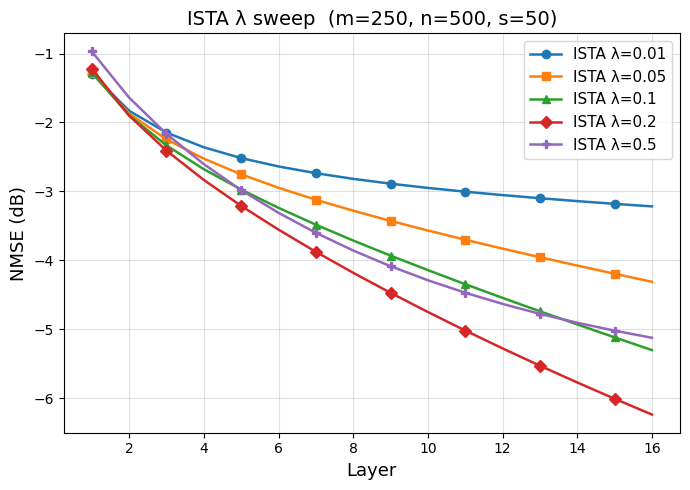

In [5]:
lambda_vals = [0.01, 0.05, 0.1, 0.2, 0.5]
lam_results = {}

for lam in lambda_vals:
    m = ISTA(A, lam=lam, n_iter=N_LAYERS).to(DEVICE)
    nmse_list = get_layerwise_nmse(m, test_loader, DEVICE)
    lam_results[f'ISTA λ={lam}'] = nmse_list

fig = plot_nmse_vs_layers(
    lam_results,
    title=f'ISTA λ sweep  (m={M}, n={N}, s={S})',
)
plt.show()

## 5. ISTA vs FISTA

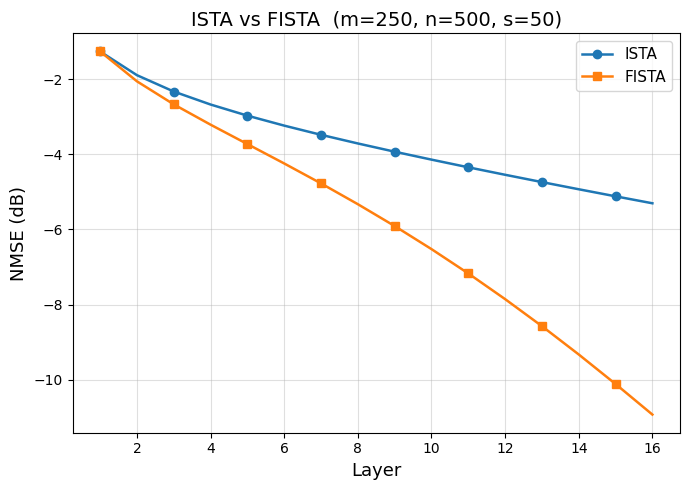

In [6]:
fig = plot_nmse_vs_layers(
    {'ISTA': ista_nmse, 'FISTA': fista_nmse},
    title=f'ISTA vs FISTA  (m={M}, n={N}, s={S})',
)
plt.show()

## 6. Full Metrics on Test Set

In [7]:
rows = []
for name, model in [('ISTA', ista), ('FISTA', fista)]:
    res = evaluate_model(model, test_loader, DEVICE)
    rows.append({'Model': name, **res})

df = pd.DataFrame(rows).set_index('Model')
print(df[['nmse_db', 'runtime_ms', 'n_params']].to_string())

         nmse_db  runtime_ms  n_params
Model                                 
ISTA   -5.303477    5.324272         0
FISTA -10.921586    6.335286         0
